In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import torch

from ppdr.utils.dataset import HypersimDataset
from ppdr.utils.geometry import depth_to_point_cloud, edge_mask
from ppdr.utils.reader import HypersimReader
from ppdr.utils.transform import image_tensor2array


In [4]:
reader = HypersimReader("../data/hypersim_test_set")
dataset = HypersimDataset(reader)

entry = dataset.get_entry_by_name("ai_048_010_cam_03_47")
image = entry["image"]
real_depth = entry["depth"]
valid_mask = entry["valid_mask"]
ndc_to_cam = entry["ndc_to_cam"]

In [5]:
mask = edge_mask(image.unsqueeze(0), canny_low=0.01, canny_high=0.1, dilation_px=4)


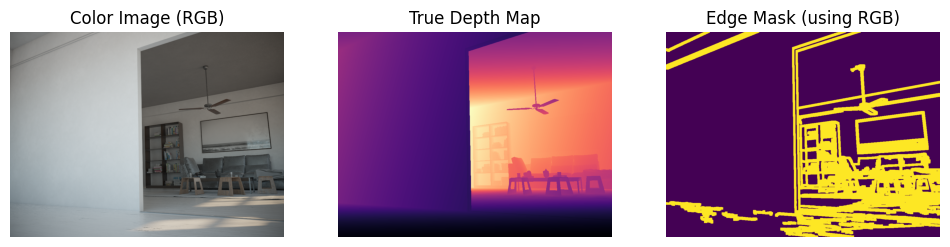

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(image_tensor2array(image))
axes[0].set_title("Color Image (RGB)")
axes[0].axis("off")

axes[1].imshow(real_depth.numpy(), "magma")
axes[1].set_title("True Depth Map")
axes[1].axis("off")

axes[2].imshow(mask.squeeze().numpy())
axes[2].set_title("Edge Mask (using RGB)")
axes[2].axis("off")

plt.show()

In [7]:
colors = image_tensor2array(image)[valid_mask.numpy()]
real_points = depth_to_point_cloud(real_depth, ndc_to_cam, valid_mask).numpy()

In [8]:
from ppdr.utils.geometry import (
    recover_metric_depth_from_disparity,
    recover_metric_depth_from_log,
)
from ppdr.utils.heuristic import clean_flying_pixels

ppd_depth = torch.load("ppd_depth.pt")
dav2_disp = torch.load("dav2_disp.pt")

ppd_depth = recover_metric_depth_from_log(ppd_depth, real_depth, valid_mask)
dav2_depth = recover_metric_depth_from_disparity(dav2_disp, real_depth, valid_mask)


/tmp/ipykernel_1622820/264155593.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Widget(value='<iframe src="http://localhost:45443/index.html?ui=P_0x7d876bfd5a20_0&reconnect=auto" class="pyvi…

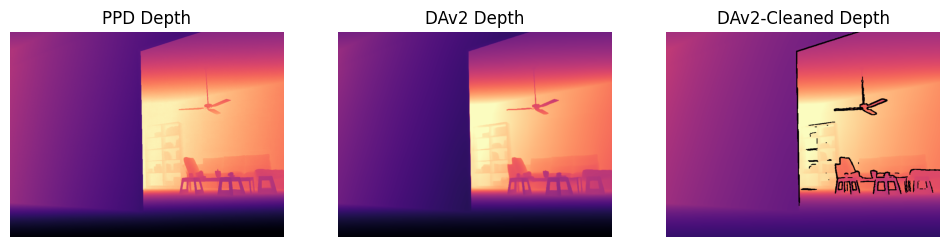

In [9]:
import pyvista as pv

dav2cleaned_depth = clean_flying_pixels(
    dav2_depth.unsqueeze(0), image.unsqueeze(0)
).squeeze()

dav2cleaned_points = depth_to_point_cloud(
    dav2cleaned_depth, ndc_to_cam, valid_mask
).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(ppd_depth.numpy(), "magma")
axes[0].set_title("PPD Depth")
axes[0].axis("off")

axes[1].imshow(dav2_depth.numpy(), "magma")
axes[1].set_title("DAv2 Depth")
axes[1].axis("off")

axes[2].imshow(dav2cleaned_depth.numpy(), "magma")
axes[2].set_title("DAv2-Cleaned Depth")
axes[2].axis("off")

fig.show()

plotter = pv.Plotter(notebook=True)
plotter.add_mesh(
    dav2cleaned_points,
    scalars=colors,
    render_points_as_spheres=True,
    point_size=2.0,
    cmap="viridis",
)
plotter.show()